In [1]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
tickers = ["JPM", "GS", "BAC", "MS"]
nombres = {
    "JPM": "JPMorgan Chase",
    "GS": "Goldman Sachs",
    "BAC": "Bank of America",
    "MS": "Morgan Stanley"
}


datos = yf.download(tickers, period="2y", auto_adjust=True)['Close']
print("✅ Datos descargados correctamente")
print(f"Período: {datos.index[0].date()} → {datos.index[-1].date()}")
print(f"Total de días: {len(datos)}")
datos.tail()

[*********************100%***********************]  4 of 4 completed

✅ Datos descargados correctamente
Período: 2024-05-06 → 2026-05-05
Total de días: 501


Ticker,BAC,GS,JPM,MS
Date,,,,
2026-04-29,52.880001,905.599976,309.250000,186.080002
2026-04-30,53.459999,923.770020,313.230011,190.589996
2026-05-01,53.240002,923.710022,312.470001,190.169998
2026-05-04,52.189999,903.270020,307.649994,188.009995
2026-05-05,53.169998,920.159973,309.660004,189.929993


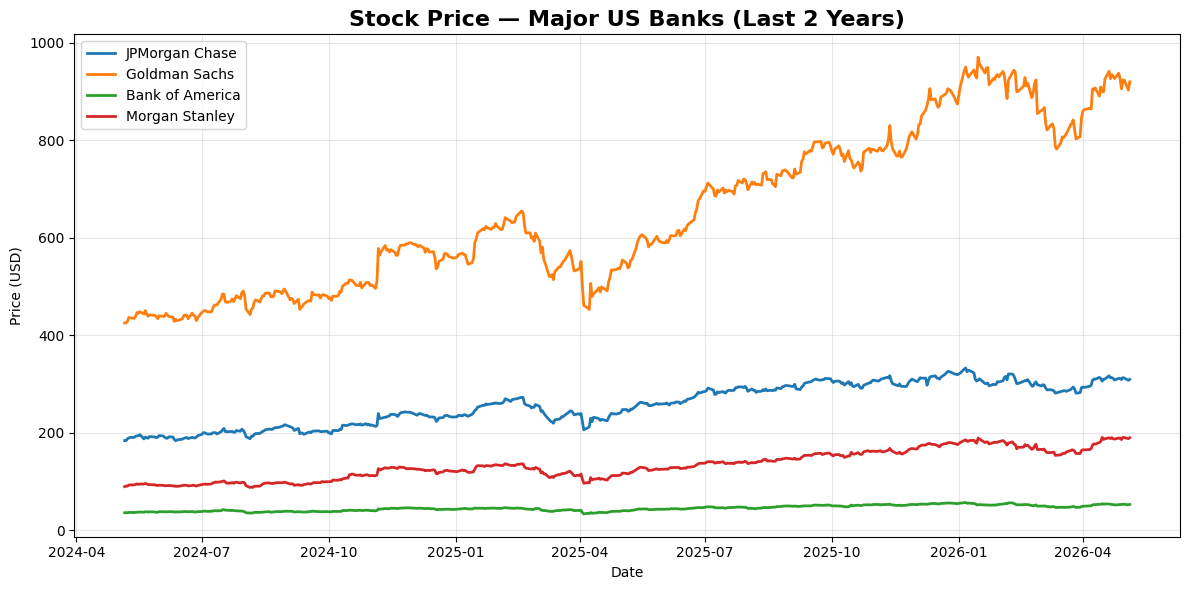

✅ Gráfico guardado


In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in tickers:
    ax.plot(datos.index, datos[ticker], label=nombres[ticker], linewidth=2)

ax.set_title("Stock Price — Major US Banks (Last 2 Years)", fontsize=16, fontweight='bold')
ax.set_ylabel("Price (USD)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("stock_prices.png", dpi=150)
plt.show()
print("✅ Gráfico guardado")

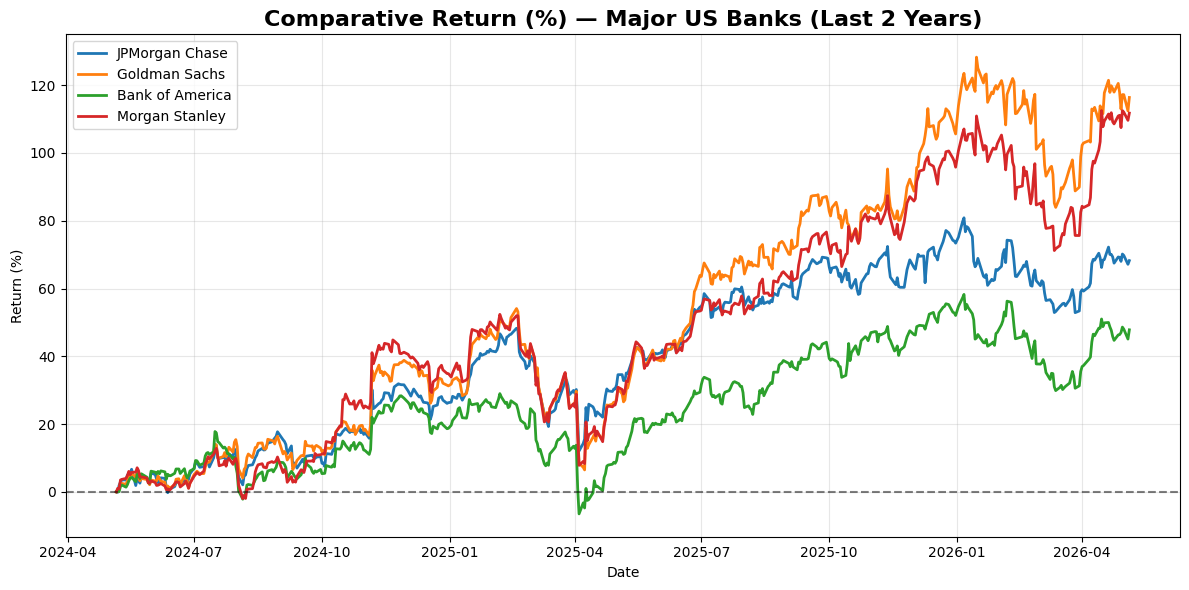

In [4]:
rendimiento = (datos / datos.iloc[0] - 1) * 100

fig, ax = plt.subplots(figsize=(12, 6))

for ticker in tickers:
    ax.plot(rendimiento.index, rendimiento[ticker], label=nombres[ticker], linewidth=2)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_title("Comparative Return (%) — Major US Banks (Last 2 Years)", fontsize=16, fontweight='bold')
ax.set_ylabel("Return (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("comparative_return.png", dpi=150)
plt.show()

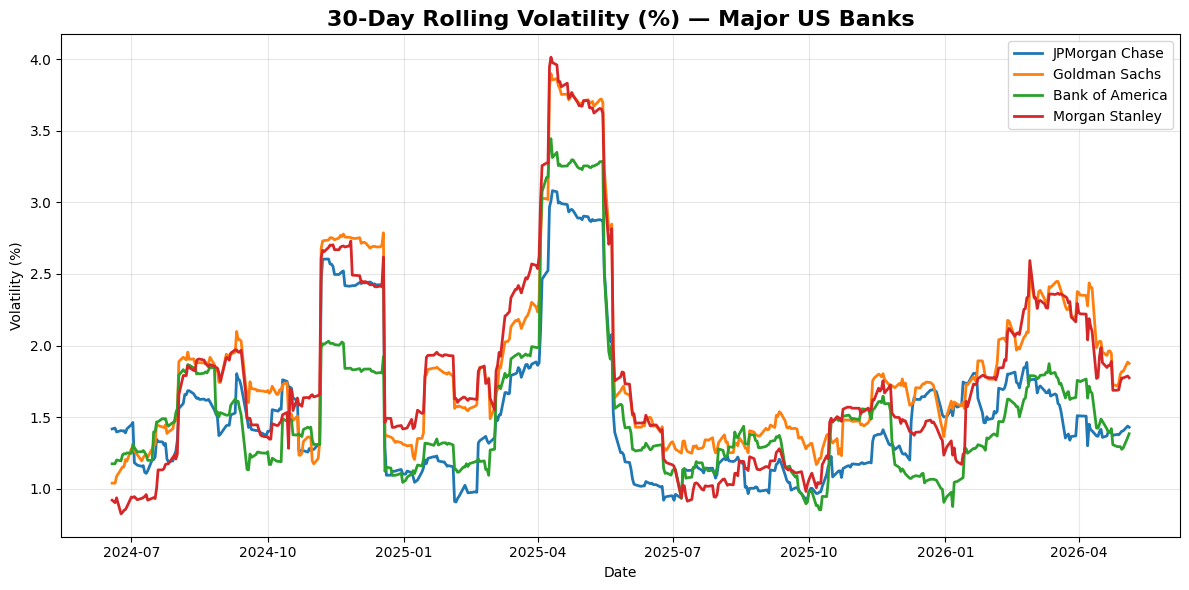

In [5]:
retornos_diarios = datos.pct_change()
volatilidad = retornos_diarios.rolling(window=30).std() * 100

fig, ax = plt.subplots(figsize=(12, 6))

for ticker in tickers:
    ax.plot(volatilidad.index, volatilidad[ticker], label=nombres[ticker], linewidth=2)

ax.set_title("30-Day Rolling Volatility (%) — Major US Banks", fontsize=16, fontweight='bold')
ax.set_ylabel("Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("volatility.png", dpi=150)
plt.show()

In [6]:
resumen = pd.DataFrame({
    'Bank': [nombres[t] for t in tickers],
    'Current Price (USD)': [round(datos[t].iloc[-1], 2) for t in tickers],
    'Total Return (%)': [round(rendimiento[t].iloc[-1], 2) for t in tickers],
    'Avg Daily Volatility (%)': [round(retornos_diarios[t].std() * 100, 3) for t in tickers],
    'Max Price (USD)': [round(datos[t].max(), 2) for t in tickers],
    'Min Price (USD)': [round(datos[t].min(), 2) for t in tickers],
})

resumen = resumen.sort_values('Total Return (%)', ascending=False).reset_index(drop=True)
print("\n📊 SUMMARY — Major US Banks Performance (Last 2 Years)")
print("="*70)
print(resumen.to_string(index=False))


📊 SUMMARY — Major US Banks Performance (Last 2 Years)
           Bank  Current Price (USD)  Total Return (%)  Avg Daily Volatility (%)  Max Price (USD)  Min Price (USD)
  Goldman Sachs               920.16            116.36                     1.931           970.75           425.28
 Morgan Stanley               189.93            111.76                     1.882           190.60            87.90
 JPMorgan Chase               309.66             68.23                     1.585           332.91           183.62
Bank of America                53.17             47.81                     1.597            56.93            33.63
